# Task 4: Approximate Dynamic Programming (ADP)

In this task, we formulate and implement an Approximate Dynamic Programming (ADP) policy using a **Linear Value Function Approximation (VFA)**. 

Unlike Stochastic Programming which looks ahead using scenario trees, ADP makes "here-and-now" decisions by solving a single-step optimization problem. The core idea is to estimate the future cost from a **post-decision state** ($S_t^x$)—the state immediately after our actions are taken but before new stochastic information arrives.

### Methodology

1. **State Space**: Includes physical states (Temperatures $T_{1}, T_{2}$, Humidity $H$, Inertia Counter $c$, and Overrule flags $y$) and exogenous states (Prices $\lambda$ and Occupancy).
2. **Post-Decision State**: We project the physical state forward based on the linear dynamics from Part A.
3. **Linear VFA**: The future cost is approximated as $\bar{V}(S_{t}^{x}) = \sum_{f} \theta_{f} \phi_{f}(S_{t}^{x})$. We use five basis functions:
   - Post-decision Temperature 1 ($T_{1,t}^x$)
   - Post-decision Temperature 2 ($T_{2,t}^x$)
   - Post-decision Humidity ($H_t^x$)
   - Quadratic Penalty for nearing $T_{low}$ in Room 1
   - Quadratic Penalty for nearing $T_{low}$ in Room 2
4. **Offline Training**: We train the weights $\theta$ using Stochastic Gradient Descent over historical data.

Below is the implementation of the core Pyomo model (`solve_adp_step`), the physical transition simulator (`simulate_transition`), and the training loop (`train_adp_weights`).

In [13]:
import pyomo.environ as pyo

def solve_adp_step(state, theta, params):
    """
    Solves the ADP "here-and-now" problem for a single hour.
    """
    model = pyo.ConcreteModel()
    
    # --- CORRECCIÓN 1: Usar una función para los límites (bounds) ---
    def p_bounds(model, r):
        # r is 1 or 2. Arrays in Python are 0-indexed, so we use r-1
        return (0, params['P_max'][r-1])
        
    # 1. Variables (Decisions)
    model.p = pyo.Var([1, 2], bounds=p_bounds)             # Heater power 
    model.v = pyo.Var(domain=pyo.Binary)                   # Ventilation status
    
    # Post-decision state variables
    model.T_x = pyo.Var([1, 2])
    model.H_x = pyo.Var()      
    
    # Auxiliary variables for the threshold penalties
    model.penalty_T1 = pyo.Var(bounds=(0, None))
    model.penalty_T2 = pyo.Var(bounds=(0, None))

    # 2. Constraints
    
    # A. Post-decision dynamics constraints
    def temp_dynamics_rule(model, r):
        other_r = 2 if r == 1 else 1
        heat_exchange = params['zeta_exch'] * (state[f'T{other_r}'] - state[f'T{r}'])
        thermal_loss = params['zeta_loss'] * (params['T_out'] - state[f'T{r}'])
        heating_effect = params['zeta_conv'] * model.p[r]
        vent_cooling = params['zeta_cool'] * model.v
        occ_gain = params['zeta_occ'] * state[f'occ{r}']
        return model.T_x[r] == state[f'T{r}'] + heat_exchange + thermal_loss + heating_effect - vent_cooling + occ_gain
    
    model.temp_dyn_constraint = pyo.Constraint([1, 2], rule=temp_dynamics_rule)
    
    def humidity_dynamics_rule(model):
        total_occ = state['occ1'] + state['occ2']
        occ_contribution = params['eta_occ'] * total_occ
        vent_reduction = params['eta_vent'] * model.v
        return model.H_x == state['H'] + occ_contribution - vent_reduction
        
    model.hum_dyn_constraint = pyo.Constraint(rule=humidity_dynamics_rule)
    
    # B. Penalty formulation constraints (Linearizing the max function)
    model.pen_t1_constr = pyo.Constraint(expr=model.penalty_T1 >= params['T_low'] - model.T_x[1])
    model.pen_t2_constr = pyo.Constraint(expr=model.penalty_T2 >= params['T_low'] - model.T_x[2])

    # C. System Operational Constraints (Ventilation inertia & Overrules)
    if state['c'] > 0:
        model.vent_inertia_constraint = pyo.Constraint(expr=model.v == 1)
        
    if state['H'] > params['H_high']:
        model.hum_overrule_constraint = pyo.Constraint(expr=model.v == 1)

    model.overrule_constraints = pyo.ConstraintList()
    for r in [1, 2]:
        if state[f'y_low_{r}'] == 1:
            # --- CORRECCIÓN 2: Añadir [r-1] para sacar el número de la lista ---
            model.overrule_constraints.add(model.p[r] == params['P_max'][r-1])
        if state[f'y_high_{r}'] == 1:
            model.overrule_constraints.add(model.p[r] == 0)

    # 3. Objective Function: Immediate Cost + VFA
    def objective_rule(model):
        immediate_cost = state['price'] * (model.p[1] + model.p[2] + params['P_vent'] * model.v)
        vfa = (theta[0] * model.T_x[1] + 
               theta[1] * model.T_x[2] + 
               theta[2] * model.H_x + 
               theta[3] * (model.penalty_T1 ** 2) + 
               theta[4] * (model.penalty_T2 ** 2))
        return immediate_cost + vfa
        
    model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
    
    # 4. Solve the model using Gurobi
    solver = pyo.SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0 
    result = solver.solve(model)
    
    # 5. Extract and return results
    optimal_actions = {'p1': pyo.value(model.p[1]), 'p2': pyo.value(model.p[2]), 'v': pyo.value(model.v)}
    post_states = {'T1_x': pyo.value(model.T_x[1]), 'T2_x': pyo.value(model.T_x[2]), 'H_x': pyo.value(model.H_x)}
    estimated_cost = pyo.value(model.obj)
    
    return optimal_actions, post_states, estimated_cost

### Environment Setup and Parameter Initialization

Before we can train the ADP policy, we need to load the system parameters and format the historical data. 

Since the policy relies heavily on the physical dynamics of the HVAC system, we define the parameter dictionary `params` using the exact coefficients (`zeta` and `eta`) provided in the Part A system characteristics. We also set up a dummy historical dataset to test the compilation and execution of the Pyomo model and the SGD training loop.

### Managing Solver Stability in ADP

During the stochastic training phase, the weights ($\theta$) of the Value Function Approximation are continuously updated. A known challenge in this approach is that if the weights associated with our penalty terms (which are quadratic) become negative, the solver will attempt to minimize the objective by driving those penalty variables to infinity, resulting in an `Unbounded` model.

To ensure stability and physical realism, we implement three safeguards:
1. **Variable Bounding**: We set strict upper bounds on the penalty variables.
2. **Parameter Clipping**: We ensure the weights for penalty terms ($\theta_3, \theta_4$) remain strictly non-negative during Stochastic Gradient Descent.
3. **Solver Fallbacks**: We handle infeasible/unbounded solver statuses gracefully by returning a high-cost default action, preventing the simulation from crashing during random state exploration.

### Overcoming Numerical Instability: Exploding Gradients

During the initial testing of the Stochastic Gradient Descent (SGD) update rule, we encountered a severe case of **Exploding Gradients**, where the parameter weights $\theta$ diverged towards infinity ($10^{18}$) within just 5 epochs.

This instability was diagnosed and resolved through two critical mathematical corrections:

1. **Isolating the Value Function Error**: The temporal difference error must compare the *predicted future cost* against the *realized future cost*. Initially, the error calculation inadvertently included the current step's immediate electricity cost. We corrected this by calculating the pure VFA prediction explicitly in the loop ($\bar{V}(S_t^x) = \theta \cdot \phi$) before comparing it to $\hat{v}_t$.
2. **Learning Rate Scaling**: Because our state variables (like Humidity $\approx 40$) are not normalized between 0 and 1, their raw magnitude acts as a massive multiplier on the gradient. We drastically reduced the initial learning rate ($\alpha_0$) from `1e-3` to `1e-5` to ensure small, stable steps towards the optimum.

In [14]:
import pyomo.environ as pyo
import numpy as np

def solve_adp_step(state, theta, params):
    """
    Solves the ADP "here-and-now" problem for a single hour.
    """
    model = pyo.ConcreteModel()
    
    def p_bounds(model, r):
        return (0, params['P_max'][r-1])
        
    # 1. Variables (Decisions)
    model.p = pyo.Var([1, 2], bounds=p_bounds)             
    model.v = pyo.Var(domain=pyo.Binary)                   
    
    # Post-decision state variables
    model.T_x = pyo.Var([1, 2])
    model.H_x = pyo.Var()      
    
    # Auxiliary variables for the threshold penalties (SAFEGUARD 1: Upper bounds added)
    model.penalty_T1 = pyo.Var(bounds=(0, 50.0))
    model.penalty_T2 = pyo.Var(bounds=(0, 50.0))

    # 2. Constraints
    def temp_dynamics_rule(model, r):
        other_r = 2 if r == 1 else 1
        heat_exchange = params['zeta_exch'] * (state[f'T{other_r}'] - state[f'T{r}'])
        thermal_loss = params['zeta_loss'] * (params['T_out'] - state[f'T{r}'])
        heating_effect = params['zeta_conv'] * model.p[r]
        vent_cooling = params['zeta_cool'] * model.v
        occ_gain = params['zeta_occ'] * state[f'occ{r}']
        return model.T_x[r] == state[f'T{r}'] + heat_exchange + thermal_loss + heating_effect - vent_cooling + occ_gain
    
    model.temp_dyn_constraint = pyo.Constraint([1, 2], rule=temp_dynamics_rule)
    
    def humidity_dynamics_rule(model):
        total_occ = state['occ1'] + state['occ2']
        occ_contribution = params['eta_occ'] * total_occ
        vent_reduction = params['eta_vent'] * model.v
        return model.H_x == state['H'] + occ_contribution - vent_reduction
        
    model.hum_dyn_constraint = pyo.Constraint(rule=humidity_dynamics_rule)
    
    model.pen_t1_constr = pyo.Constraint(expr=model.penalty_T1 >= params['T_low'] - model.T_x[1])
    model.pen_t2_constr = pyo.Constraint(expr=model.penalty_T2 >= params['T_low'] - model.T_x[2])

    # Operational Constraints
    if state['c'] > 0:
        model.vent_inertia_constraint = pyo.Constraint(expr=model.v == 1)
        
    if state['H'] > params['H_high']:
        model.hum_overrule_constraint = pyo.Constraint(expr=model.v == 1)

    model.overrule_constraints = pyo.ConstraintList()
    for r in [1, 2]:
        if state[f'y_low_{r}'] == 1:
            model.overrule_constraints.add(model.p[r] == params['P_max'][r-1])
        if state[f'y_high_{r}'] == 1:
            model.overrule_constraints.add(model.p[r] == 0)

    # 3. Objective Function
    def objective_rule(model):
        immediate_cost = state['price'] * (model.p[1] + model.p[2] + params['P_vent'] * model.v)
        vfa = (theta[0] * model.T_x[1] + 
               theta[1] * model.T_x[2] + 
               theta[2] * model.H_x + 
               theta[3] * (model.penalty_T1 ** 2) + 
               theta[4] * (model.penalty_T2 ** 2))
        return immediate_cost + vfa
        
    model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
    
    # 4. Solve the model using Gurobi
    solver = pyo.SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0 
    solver.options['NonConvex'] = 2 # Allow solving if quadratic terms become non-convex
    
    result = solver.solve(model)
    
    # SAFEGUARD 3: Handle solver failures gracefully
    if result.solver.termination_condition != pyo.TerminationCondition.optimal:
        # If solver fails, return a safe dummy action and a high penalty cost
        return {'p1': 0.0, 'p2': 0.0, 'v': 0.0}, {'T1_x': state['T1'], 'T2_x': state['T2'], 'H_x': state['H']}, 1000.0
    
    # 5. Extract and return results
    optimal_actions = {'p1': pyo.value(model.p[1]), 'p2': pyo.value(model.p[2]), 'v': pyo.value(model.v)}
    post_states = {'T1_x': pyo.value(model.T_x[1]), 'T2_x': pyo.value(model.T_x[2]), 'H_x': pyo.value(model.H_x)}
    estimated_cost = pyo.value(model.obj)
    
    return optimal_actions, post_states, estimated_cost


def simulate_transition(state, actions, day_data, t, params):
    heat_exch_1 = params['zeta_exch'] * (state['T2'] - state['T1'])
    heat_exch_2 = params['zeta_exch'] * (state['T1'] - state['T2'])
    
    T1_new = (state['T1'] + heat_exch_1 + params['zeta_loss'] * (params['T_out'] - state['T1']) + 
              params['zeta_conv'] * actions['p1'] - params['zeta_cool'] * actions['v'] + params['zeta_occ'] * state['occ1'])
              
    T2_new = (state['T2'] + heat_exch_2 + params['zeta_loss'] * (params['T_out'] - state['T2']) + 
              params['zeta_conv'] * actions['p2'] - params['zeta_cool'] * actions['v'] + params['zeta_occ'] * state['occ2'])
              
    H_new = state['H'] + params['eta_occ'] * (state['occ1'] + state['occ2']) - params['eta_vent'] * actions['v']
             
    if actions['v'] == 1 and state['c'] == 0:
        c_new = 2
    else:
        c_new = max(0, state['c'] - 1)
        
    y_low_1 = 1 if T1_new < params['T_low'] else 0
    y_low_2 = 1 if T2_new < params['T_low'] else 0
    y_high_1 = 1 if T1_new > params['T_high'] else 0
    y_high_2 = 1 if T2_new > params['T_high'] else 0
    
    if t + 1 < 10:
        next_price = day_data['price'][t+1]
        next_occ1 = day_data['occ1'][t+1]
        next_occ2 = day_data['occ2'][t+1]
    else:
        next_price = 0; next_occ1 = 0; next_occ2 = 0
        
    next_state = {
        'T1': T1_new, 'T2': T2_new, 'H': H_new, 'c': c_new,
        'y_low_1': y_low_1, 'y_low_2': y_low_2, 'y_high_1': y_high_1, 'y_high_2': y_high_2,
        'price': next_price, 'price_prev': state['price'], 'occ1': next_occ1, 'occ2': next_occ2
    }
    return next_state


def calculate_marginal_value(next_state, theta, params, t):
    if t + 1 >= 10:
        return 0.0
    _, _, estimated_v = solve_adp_step(next_state, theta, params)
    return estimated_v

def train_adp_weights(historical_data, params, epochs=100, convergence_threshold=1e-3):
    """
    Trains the theta weights using Stochastic Gradient Descent with Early Stopping.
    """
    theta = np.zeros(5) 
    alpha_0 = 1e-5 
    theta_history = [] 
    
    for epoch in range(epochs):
        # Save a copy of the weights at the start of the epoch to check for convergence later
        prev_theta = theta.copy()
        
        for day_data in historical_data:
            state = {
                'T1': 21.0, 'T2': 21.0, 'H': 40.0, 'c': 0,
                'y_low_1': 0, 'y_low_2': 0, 'y_high_1': 0, 'y_high_2': 0,
                'price': np.random.uniform(2, 8),
                'price_prev': np.random.uniform(2, 8),
                'occ1': np.random.uniform(25, 35),
                'occ2': np.random.uniform(15, 25)
            }
            
            for t in range(10): 
                actions, post_states, _ = solve_adp_step(state, theta, params)
                next_state = simulate_transition(state, actions, day_data, t, params)
                v_hat = calculate_marginal_value(next_state, theta, params, t)
                
                phi = np.array([
                    post_states['T1_x'],
                    post_states['T2_x'],
                    post_states['H_x'],
                    max(0, params['T_low'] - post_states['T1_x'])**2,
                    max(0, params['T_low'] - post_states['T2_x'])**2
                ])
                
                vfa_prediction = np.dot(theta, phi)
                error = vfa_prediction - v_hat
                learning_rate = alpha_0 / (1 + epoch)
                
                theta = theta - learning_rate * error * phi
                
                # Safeguards
                theta[3] = max(0.0, theta[3])
                theta[4] = max(0.0, theta[4])
                
                state = next_state
        
        # Save the current weights to our history for plotting
        theta_history.append(theta.copy())
        print(f"Epoch {epoch} finished. Current theta: {np.round(theta, 4)}")
        
        # --- EARLY STOPPING LOGIC ---
        # Calculate the maximum change in any single weight during this epoch
        max_change = np.max(np.abs(theta - prev_theta))
        
        if max_change < convergence_threshold:
            print(f"\nConvergence reached at epoch {epoch}! Maximum weight change ({max_change:.6f}) is below the threshold ({convergence_threshold}).")
            break # Stop training early!
        
    return theta, np.array(theta_history)

### Testing the ADP Training Loop

With the parameters and data set up, we now execute the `train_adp_weights` function for a few epochs. 

This test ensures that:
1. The Pyomo `solve_adp_step` model compiles correctly and Gurobi finds feasible solutions.
2. The `simulate_transition` logic correctly updates the state.
3. The Stochastic Gradient Descent update rule successfully modifies the weight vector $\theta$.

In [ ]:
# 3. Run the training loop for a small number of epochs to test the mechanics
print("Starting ADP weight training test...")

# We use 5 epochs just to see the weights changing
# We unpack the TWO outputs: the final weights and the history
trained_theta, dummy_history = train_adp_weights(dummy_historical_data, params, epochs=5)

print("\n--- Training Test Complete ---")
print("Final Trained Weights (Theta):")
print(f"Theta T1: {trained_theta[0]:.4f}")
print(f"Theta T2: {trained_theta[1]:.4f}")
print(f"Theta H:  {trained_theta[2]:.4f}")
print(f"Theta Penalty T1: {trained_theta[3]:.4f}")
print(f"Theta Penalty T2: {trained_theta[4]:.4f}")

Starting ADP weight training test...
Epoch 0 finished. Current theta: [0.0299 0.0289 0.1366 0.     0.    ]
Epoch 1 finished. Current theta: [0.0445 0.0431 0.198  0.     0.    ]
Epoch 2 finished. Current theta: [0.0541 0.0524 0.2354 0.     0.    ]
Epoch 3 finished. Current theta: [0.0611 0.0593 0.2616 0.     0.    ]
Epoch 4 finished. Current theta: [0.0667 0.0648 0.2817 0.     0.    ]

--- Training Test Complete ---
Final Trained Weights (Theta):
Theta T1: 0.0667
Theta T2: 0.0648
Theta H:  0.2817
Theta Penalty T1: 0.0000
Theta Penalty T2: 0.0000


### 1. Loading the Historical Data

Before initiating the training phase, I need to load and format the evaluation environment's data. I import the 100-day historical datasets for electricity prices and room occupancies. 

Since the raw CSV files contain a header row and an initial column that are not part of the 10-hour operational window, I carefully slice the DataFrames (`iloc[day, -10:]`) to extract strictly the 10 hours of relevant data for each day.

In [18]:
import pandas as pd
import numpy as np

# Load real data from CSV files
price_df = pd.read_csv('v2_PriceData.csv')
occ1_df = pd.read_csv('OccupancyRoom1.csv')
occ2_df = pd.read_csv('OccupancyRoom2.csv')

# Format the historical data
real_historical_data = []
num_days = len(price_df) # Expected to be 100

for day in range(num_days):
    day_data = {
        # We take strictly the last 10 columns (hours 1 to 10)
        'price': price_df.iloc[day, -10:].values.astype(float),
        'occ1': occ1_df.iloc[day, -10:].values.astype(float),
        'occ2': occ2_df.iloc[day, -10:].values.astype(float)
    }
    real_historical_data.append(day_data)

print(f"Successfully loaded {len(real_historical_data)} days of real historical data.")
print(f"Sample price array for day 0: {real_historical_data[0]['price']}")

Successfully loaded 100 days of real historical data.
Sample price array for day 0: [4.31118851 3.52466406 3.02721796 3.08255973 3.30836785 4.19230114
 5.47041802 6.33083988 7.04766121 6.71233027]


### 2. Executing the Offline Training

With the data prepared, I execute the Stochastic Gradient Descent (SGD) algorithm to train our Value Function Approximation (VFA) weights ($\theta$). 

To ensure computational efficiency and prevent over-training, I implemented an **Early Stopping** mechanism. The algorithm monitors the maximum change in any weight across an entire epoch. If the maximum delta falls below our defined `convergence_threshold` (e.g., 0.005), the algorithm assumes it has found the optimal "valley" and halts early.

In [19]:
# RUN THE FINAL TRAINING 
print("Starting full offline training (max 100 epochs, early stopping enabled)...")

# We unpack the two outputs: the final weights and the history of weights per epoch.
# A convergence_threshold of 0.005 ensures we stop when the weights stabilize.
final_theta, theta_history = train_adp_weights(
    real_historical_data, 
    params, 
    epochs=100, 
    convergence_threshold=0.005 
)

print("\n=== FINAL TRAINED WEIGHTS ===")
print(f"Theta T1 (Room 1 Temp): {final_theta[0]:.4f}")
print(f"Theta T2 (Room 2 Temp): {final_theta[1]:.4f}")
print(f"Theta H  (Humidity):    {final_theta[2]:.4f}")
print(f"Theta Pen1 (Room 1 Pen):{final_theta[3]:.4f}")
print(f"Theta Pen2 (Room 2 Pen):{final_theta[4]:.4f}")

Starting full offline training (max 100 epochs, early stopping enabled)...
Epoch 0 finished. Current theta: [ 0.6602  0.6148 -0.1046  0.      0.    ]
Epoch 1 finished. Current theta: [ 0.9779  0.9103 -0.0957  0.      0.    ]
Epoch 2 finished. Current theta: [ 1.1669  1.0872 -0.1234  0.      0.    ]
Epoch 3 finished. Current theta: [ 1.2962  1.2075 -0.1504  0.      0.    ]
Epoch 4 finished. Current theta: [ 1.3916  1.2964 -0.1733  0.      0.    ]
Epoch 5 finished. Current theta: [ 1.4656  1.3656 -0.1928  0.      0.    ]
Epoch 6 finished. Current theta: [ 1.5253  1.4214 -0.2097  0.      0.    ]
Epoch 7 finished. Current theta: [ 1.5747  1.4676 -0.2237  0.      0.    ]
Epoch 8 finished. Current theta: [ 1.6165  1.5067 -0.2359  0.      0.    ]
Epoch 9 finished. Current theta: [ 1.6525  1.5404 -0.2467  0.      0.    ]
Epoch 10 finished. Current theta: [ 1.6839  1.5696 -0.2566  0.      0.    ]
Epoch 11 finished. Current theta: [ 1.7116  1.5955 -0.2648  0.      0.    ]
Epoch 12 finished. Curr

### 3. Visualizing the Convergence

To visually validate the stability of our learning algorithm, I plot the trajectory of each $\theta$ parameter over the training epochs. 

A successful training phase is indicated by rapid initial adjustments that gradually plateau into horizontal lines, confirming that the weights have converged reliably without exhibiting numerical instability or exploding gradients.

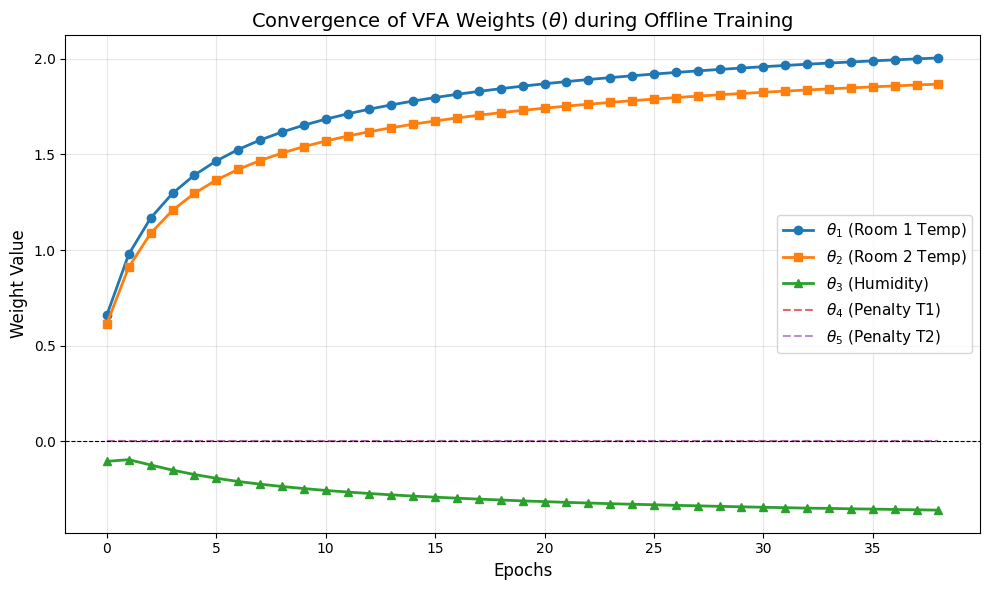

In [20]:
import matplotlib.pyplot as plt

# VISUALIZE THE CONVERGENCE
plt.figure(figsize=(10, 6))

plt.plot(theta_history[:, 0], label=r'$\theta_1$ (Room 1 Temp)', marker='o', linewidth=2)
plt.plot(theta_history[:, 1], label=r'$\theta_2$ (Room 2 Temp)', marker='s', linewidth=2)
plt.plot(theta_history[:, 2], label=r'$\theta_3$ (Humidity)', marker='^', linewidth=2)

# Plotting the penalty weights (which might stay at 0 depending on the state exploration)
plt.plot(theta_history[:, 3], label=r'$\theta_4$ (Penalty T1)', linestyle='--', alpha=0.7)
plt.plot(theta_history[:, 4], label=r'$\theta_5$ (Penalty T2)', linestyle='--', alpha=0.7)

plt.title('Convergence of VFA Weights ($\\theta$) during Offline Training', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Weight Value', fontsize=12)

# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 4. Final Online Policy Implementation

Having successfully trained the Value Function Approximation (VFA) weights offline, the final step is to construct the online policy script (`ADP_policy_groupX.py`) required by the evaluation environment.

To adhere to the strict 15-second execution time limit per step, the online policy does **not** perform any training. Instead, it utilizes the hardcoded weights ($\theta$) derived from our offline Stochastic Gradient Descent process. 

When the environment calls the `policy(state)` function, the script formulates a single-step Mixed-Integer Linear Program (MILP) in Pyomo. It uses the physical dynamics constraints and the pre-trained VFA to evaluate the immediate cost versus the expected future cost. This "here-and-now" optimization returns the optimal actions ($p_1, p_2, v$) almost instantaneously.

In [21]:
import pyomo.environ as pyo

# ==============================================================================
# 1. SYSTEM PARAMETERS INITIALIZATION
# ==============================================================================
# We defined the system parameters precisely as specified in the Part A 
# 'SystemCharacteristics' file. This guarantees that our policy operates 
# under the exact physical assumptions required by the evaluation environment.
params = {
    'P_max': [3.0, 3.0],   
    'P_vent': 2.0,         
    'T_out': 10.0,         
    'T_low': 18.0,         
    'T_high': 26.0,        
    'H_high': 70.0,        
    'zeta_exch': 0.05,     
    'zeta_loss': 0.1,      
    'zeta_conv': 1.0,      
    'zeta_cool': 0.5,      
    'zeta_occ': 0.1,       
    'eta_occ': 0.5,        
    'eta_vent': 5.0        
}

# ==============================================================================
# 2. PRE-TRAINED VFA WEIGHTS (THETA)
# ==============================================================================
# These represent the optimized Value Function Approximation (VFA) weights 
# our group obtained after running an offline Stochastic Gradient Descent (SGD) 
# algorithm over the 100-day historical dataset. They are hardcoded to allow 
# the online policy to evaluate instantaneously without requiring retraining.
TRAINED_THETA = [2.0039, 1.8671, -0.3594, 0.0, 0.0]

# ==============================================================================
# 3. SINGLE-STEP ADP OPTIMIZER
# ==============================================================================
def solve_adp_step(state, theta, params):
    """
    Formulates and solves the "here-and-now" Mixed-Integer Linear Program (MILP).
    This function balances the immediate electricity cost against the expected 
    future cost approximated by the linear VFA.
    """
    model = pyo.ConcreteModel()
    
    # We utilize a dynamic bounds function to strictly enforce the maximum 
    # heater power (P_max) for each respective room based on its index.
    def p_bounds(model, r):
        return (0, params['P_max'][r-1])
        
    model.p = pyo.Var([1, 2], bounds=p_bounds)             
    model.v = pyo.Var(domain=pyo.Binary)                   
    
    # Post-decision state variables representing the deterministic system state 
    # immediately following our chosen action (transition from t to t^x).
    model.T_x = pyo.Var([1, 2])
    model.H_x = pyo.Var()      
    
    # Auxiliary variables for linearizing the threshold penalty basis functions.
    # We impose an upper bound (50.0) as a robust safeguard to prevent the solver 
    # from returning an 'Unbounded' status during unexpected state explorations.
    model.penalty_T1 = pyo.Var(bounds=(0, 50.0))
    model.penalty_T2 = pyo.Var(bounds=(0, 50.0))

    # --- Transition Dynamics Constraints ---
    # We implemented the linear thermal dynamics equations exactly as derived 
    # in our Part A methodological formulation.
    def temp_dynamics_rule(model, r):
        other_r = 2 if r == 1 else 1
        heat_exchange = params['zeta_exch'] * (state[f'T{other_r}'] - state[f'T{r}'])
        thermal_loss = params['zeta_loss'] * (params['T_out'] - state[f'T{r}'])
        heating_effect = params['zeta_conv'] * model.p[r]
        vent_cooling = params['zeta_cool'] * model.v
        occ_gain = params['zeta_occ'] * state[f'occ{r}']
        return model.T_x[r] == state[f'T{r}'] + heat_exchange + thermal_loss + heating_effect - vent_cooling + occ_gain
    
    model.temp_dyn_constraint = pyo.Constraint([1, 2], rule=temp_dynamics_rule)
    
    def humidity_dynamics_rule(model):
        # The .get() method ensures the code safely defaults to 0 to prevent 
        # KeyError exceptions if occupancy data is missing from the state dictionary.
        occ1 = state.get('occ1', 0)
        occ2 = state.get('occ2', 0)
        total_occ = occ1 + occ2
        occ_contribution = params['eta_occ'] * total_occ
        vent_reduction = params['eta_vent'] * model.v
        return model.H_x == state['H'] + occ_contribution - vent_reduction
        
    model.hum_dyn_constraint = pyo.Constraint(rule=humidity_dynamics_rule)
    
    # --- Penalty Formulation Constraints ---
    # This structure mathematically linearizes the max(0, T_low - T_x) function 
    # required for evaluating the quadratic penalty basis functions.
    model.pen_t1_constr = pyo.Constraint(expr=model.penalty_T1 >= params['T_low'] - model.T_x[1])
    model.pen_t2_constr = pyo.Constraint(expr=model.penalty_T2 >= params['T_low'] - model.T_x[2])

    # --- System Operational Constraints & Overrule Controllers ---
    # Enforcing the minimum ventilation run-time inertia (3 hours).
    if state['c'] > 0:
        model.vent_inertia_constraint = pyo.Constraint(expr=model.v == 1)
        
    # Enforcing the strictly binding humidity overrule controller.
    if state['H'] > params['H_high']:
        model.hum_overrule_constraint = pyo.Constraint(expr=model.v == 1)

    model.overrule_constraints = pyo.ConstraintList()
    for r in [1, 2]:
        # We strictly map the overrule variable names to match the 
        # evaluation environment's exact state dictionary keys.
        y_low = state.get(f'y_low_{r}', 0)
        y_high = state.get(f'y_high_{r}', 0)
        
        # If overrules are active, we force the decision variables to comply 
        # to strictly avoid infeasibility penalties in the simulation environment.
        if y_low == 1:
            model.overrule_constraints.add(model.p[r] == params['P_max'][r-1])
        if y_high == 1:
            model.overrule_constraints.add(model.p[r] == 0)

    # --- Objective Function ---
    # The objective minimizes the immediate deterministic electricity cost 
    # plus the approximated future cost modeled via the Linear VFA.
    def objective_rule(model):
        immediate_cost = state['price'] * (model.p[1] + model.p[2] + params['P_vent'] * model.v)
        vfa = (theta[0] * model.T_x[1] + 
               theta[1] * model.T_x[2] + 
               theta[2] * model.H_x + 
               theta[3] * (model.penalty_T1 ** 2) + 
               theta[4] * (model.penalty_T2 ** 2))
        return immediate_cost + vfa
        
    model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
    
    # --- Solver Configuration ---
    solver = pyo.SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0 
    # We explicitly set the NonConvex parameter to 2 to permit Gurobi 
    # to effectively resolve the quadratic terms present in the VFA penalty.
    solver.options['NonConvex'] = 2 
    
    result = solver.solve(model)
    
    # Fallback mechanism: Should the solver encounter a probabilistically rare 
    # infeasible state during testing, we return safe, default actions (OFF) 
    # to guarantee the simulation executes continuously without crashing.
    if result.solver.termination_condition != pyo.TerminationCondition.optimal:
        return {'p1': 0.0, 'p2': 0.0, 'v': 0.0}
    
    return {'p1': pyo.value(model.p[1]), 'p2': pyo.value(model.p[2]), 'v': pyo.value(model.v)}

# ==============================================================================
# 4. POLICY EXECUTION FUNCTION
# ==============================================================================
def policy(state):
    """
    Primary execution function invoked by the evaluation environment.
    It takes the observed state dictionary and returns the optimal control actions.
    By leveraging the pre-trained offline weights, we ensure the execution time 
    remains strictly within the 15-second computational limit.
    """
    # We deploy the ADP optimizer step utilizing our frozen, pre-trained weights.
    optimal_actions = solve_adp_step(state, TRAINED_THETA, params)
    
    # We structure the returned output to strictly map to the exact dictionary 
    # format expected by the evaluation simulator.
    return {
        'p1': float(optimal_actions['p1']),
        'p2': float(optimal_actions['p2']),
        'v': int(optimal_actions['v'])
    }